In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("Branches.csv")
df

,BRANCH_ID,REGION,CITY,TOWN,BRANCH_TOWN,LAT,LON
0,637-KA1,Karadeniz,Kastamonu,ABANA,SEYDİLER,4197583330,3401138890
1,550-NE1,İç Anadolu,Nevşehir,ACIGÖL,NEVŞEHİR MERKEZ,3855289060,3450575250
2,320-DE1,Ege,Denizli,ACIPAYAM,ACIPAYAM,3743333330,2935000000
3,212-BI1,Doğu Anadolu,Bingöl,ADAKLI,BİNGÖL MERKEZ,3922817760,4048339550
4,734-İS4,Marmara,İstanbul,ADALAR,SULTANBEYLİ,4087637720,2909544400
...,...,...,...,...,...,...,...
952,11-AD3,Akdeniz,Adana,YÜREĞİR,SEYHAN,3700000000,3532133330
953,558-SI1,İç Anadolu,Sivas,ZARA,İMRANLI,3989500000,3775310000
954,734-İS2,Marmara,İstanbul,ZEYTİNBURNU,KAĞITHANE,4099063500,2889614000
955,660-TO2,Karadeniz,Tokat,ZİLE,ZİLE,4030000000,3588333330


In [13]:
df.isnull().sum()

BRANCH_ID      0
REGION         0
CITY           0
TOWN           0
BRANCH_TOWN    0
LAT            0
LON            0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 957 entries, 0 to 956
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   BRANCH_ID    957 non-null    object
 1   REGION       957 non-null    object
 2   CITY         957 non-null    object
 3   TOWN         957 non-null    object
 4   BRANCH_TOWN  957 non-null    object
 5   LAT          957 non-null    int64 
 6   LON          957 non-null    int64 
dtypes: int64(2), object(5)
memory usage: 52.5+ KB


In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["BRANCH_ID"]=le.fit_transform(df["BRANCH_ID"])
df["REGION"]=le.fit_transform(df["REGION"])
df["CITY"]=le.fit_transform(df["CITY"])
df["TOWN"]=le.fit_transform(df["TOWN"])
df["BRANCH_TOWN"]=le.fit_transform(df["BRANCH_TOWN"])
df

,BRANCH_ID,REGION,CITY,TOWN,BRANCH_TOWN,LAT,LON
0,117,4,40,0,108,4197583330,3401138890
1,97,6,55,1,97,3855289060,3450575250
2,45,2,21,2,0,3743333330,2935000000
3,22,1,16,3,25,3922817760,4048339550
4,149,5,77,4,111,4087637720,2909544400
...,...,...,...,...,...,...,...
952,2,0,0,831,109,3700000000,3532133330
953,99,6,64,832,153,3989500000,3775310000
954,147,5,77,833,72,4099063500,2889614000
955,128,4,66,835,141,4030000000,3588333330


In [20]:
id=df["BRANCH_ID"].values
town=df["TOWN"].values
x=np.array(list(zip(id,town)))
x

array([[117,   0],
       [ 97,   1],
       [ 45,   2],
       ...,
       [147, 833],
       [128, 835],
       [132, 834]], shape=(957, 2))

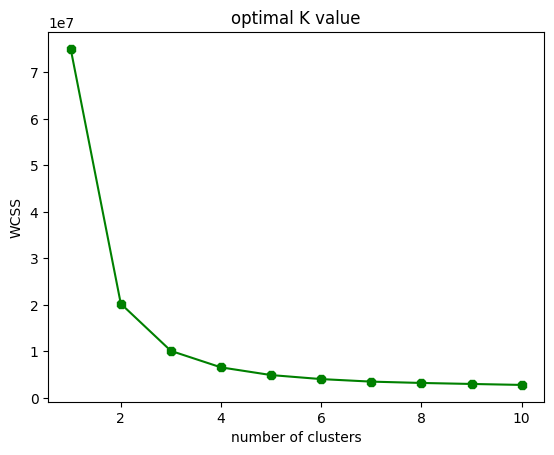

In [21]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    knn=KMeans(n_clusters=i,random_state=0)
    knn.fit(x)
    wcss.append(knn.inertia_)
plt.plot(range(1,11),wcss,color="green",marker="8")
plt.title("optimal K value")
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()

In [22]:
model=KMeans(n_clusters=3,random_state=0)
y_means=model.fit_predict(x)
y_means

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

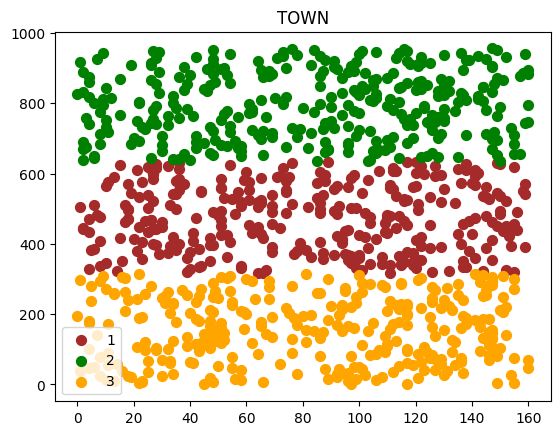

In [23]:
plt.scatter(x[y_means==0,0],x[y_means==0,1],s=50,c="brown",label="1")
plt.scatter(x[y_means==1,0],x[y_means==1,1],s=50,c="green",label="2")
plt.scatter(x[y_means==2,0],x[y_means==2,1],s=50,c="orange",label="3")
plt.title("TOWN")
plt.legend()